# Quick Start Guide

This guide will go through the basics of setting up and running fits with `Alfred`. It will teach you how to set up a directory for an exoplanet system, and then run transit and RV fits. This guide will use example data provided with the installation of `Alfred`, stored in `alfred.data_dir`, but you can follow along using your own data as well.

We will start by importing `alfred`, along with setting the way our plots will be displayed (for the purposes of this guide).

In [1]:
import alfred

import matplotlib
matplotlib.use('inline')

The first thing we need to do is create a directory to store our data, initialization files, and results for this system. `Alfred` has a built in function to guide you through this and generate the required directory structure and initialization files for it to run. It will open up the GUI for each required initialization file.

Let's first set a directory path, then run `alfred.create_folder`. Replace direc with your own directory path where you want this to be.

In [2]:
direc = '/mnt/c/Users/kroft/Documents/alfred_example/'

In [3]:
alfred.create_folder(direc)

First up, we have light curve files. The image below shows what the GUI looks like with labels for what the different fields mean.

The provided example data has a light curve file named "lc_example.csv", with time, flux, and flux error columns "t", "f", and "ferr", respectively. This fake data doesn't have a data quality column, so leave that field blank. We also need to assign this dataset a nickname to be used for light curve specific variables in the code, and I chose "ex_lc" (howerver, this can be whatever you want). The times in this dataset are offset from BJD by 2450000, so enter that there. We don't want to rescale the errors right now, so leave that at 1.0. The exposure time for this fake dataset is 120 seconds, and the fake data is supposed to represent TESS data, so select "TESS" for the filter. This light curve doesn't need detrending, so leave that box unchecked.

If you are using your own data instead of example data, you can include more light curve files by clicking add, or selecting an existing one and copying it.

Once you are done, press "Save" to save and close this file, and move on to the next one.

![lc GUI](lc_gui.jpg)

Next, we have limb darkening initialization.

Since we chose TESS as our filter for the light curve, we need to define quadratic limb darkening parameters for the TESS filter. Select TESS from the drop down filter menu again. Then, enter 0.415 for u1 and 0.1974 for u2. This data was generated for a fake planet around a real star (which we will get to soon), and these are approximate limb darkening parameters for that star.

Once you are done, press "Save" again to move on.

![ld GUI](ld_gui.jpg)

Now we will set up the the initialization for the RV files. This is very similar to setting up the light curve files.

The example rv file is called "rv_example.csv", with time, RV, and RV error columns "t", "rv", and "rverr", respectively. I will nickname it "ex_rv", and the time offset from BJD is once again 2450000. Leave the error scale alone again, and select "m/s" for the units.

Hit save to continue.

![RV file GUI](rv_gui.jpg)

Onto the stellar parameter initialization.

This fake system actually uses the stellar information for TIC 238279960. We can fill in most of the stellar parameters here ourselves:

* Radius: $0.826 \pm 0.035$
* Mass: $0.891 \pm 0.031$
* Teff: $5197 \pm 50$
* log(g): $4.496 \pm 0.1$
* Fe/H: $0.044 \pm 0.08$

We are going to use the query feature for the J magnitude and the parallax. First, press "Add Photometry" to add a photometry input box. We will continue at the next image, so keep scrolling down.

![star GUI 1](star_gui_1.jpg)

Once you have added the box for a photometric measurement, click the dropdown menu for the band and select 2MASS J. Now, select the parallax and the 2MASS J photometry using the checkmarks next to them. Then, press "Query for Selected Values", which will open a small querying popup window.

In the entry field for the catalog ID, enter "TIC 238279960" and press "Run Query". This should fill in the values and errors for the parallax (from Gaia) and the 2MASS J photometry. In case astroquery is down for some reason, you can manually enter them 7.6671 with an error of 0.0292 for the parallax, and 9.913 with an error of 0.02 for the 2MASS J band photometry.

Press save to move on to the last initialization file.

![star GUI 2](star_gui_2.jpg)

The last required initalization file to set up is for the initial planet parameters.

With the planets window open, press "Edit" next to planet 1 to open the popup to edit its parameters. We will continue at the next image, so scroll down.

![planets GUI 1](planets_gui_1.jpg)

In the popup window for planet 1, we can start by checking the boxes for "Fit Transit", "Fit RV", and "Fit Eccentricity", since we want to fit all three of these things. Then, as initial guess for the parameters, input the following:

* P: 3.1
* Tc: 10001 (note this is in BJD-2450000. `Alfred` uses this instead of normal BJD to save space.)
* Rp/Rstar: 0.1
* a/Rstar: 10
* cos(i): 0.01
* K: 150
* sqrt(e)cos(w) and sqrt(e)sin(w): 0.1 for both. This is how `Alfred` parametrizes eccentricity and the argument of periastron.

Then press "Save" to close this popup. We have no more planets to enter, so press "Save" on the main planets window to close it.

![planets GUI 2](planets_gui_2.jpg)

Now we need to move our data into the folder that you set up (it is at the location you set with direc earlier).

If you are following along using the example data, first check on the path to the directory by printing `alfred.data_dir`. Go to that directory, grab "lc_example.csv" and "rv_example.csv", and copy them to your new folder.

In [4]:
alfred.data_dir

'/home/kroft/Python/Alfred/alfred/example_data/'

Now that we have our directory set up, we can initialize an ``alfred.ExoSystem`` object from the directory. This will store all of the data and initialization parameters, and we will be able to run our fits and make plots using the object's functions.

In [5]:
exs = alfred.ExoSystem(direc)

Now we are ready to run a fit. Lets pick a name for our fit, I will call mine "example". Then we can run ``exs.fit``. We need to set a few required parameters, and there are tons more optional parameters we won't cover here. If you want to learn more about how MCMC fitting works, check out the ``emcee`` docs [here](https://emcee.readthedocs.io/en/stable/).


Initial parameters:
{'log(P) 1': 1.1314021114911006, 'Tc 1': 10001.0, 'ror 1': 0.1, 'log(a/rs) 1': 2.302585092994046, 'cos(i) 1': 0.01, 'log(K) 1': 5.0106352940962555, 'secw 1': 0.1, 'sesw 1': 0.1, 'F0 ex_lc': 1.0, 'gamma': 4526.802649424197}

Starting sigma clipping of lightcurves.


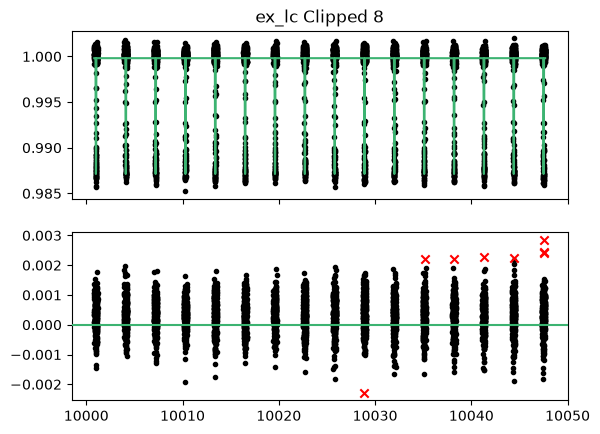


Total points clipped:
All light curves: 8
ex_lc: 8

Initial parameters after optimization:
{'log(P) 1': 1.13143928039191, 'Tc 1': 10000.999577642055, 'ror 1': 0.10293698115656749, 'log(a/rs) 1': 2.414704940726442, 'cos(i) 1': 0.01846944717222604, 'log(K) 1': 4.909826552653344, 'secw 1': -0.2387942142903977, 'sesw 1': 0.29787106373357786, 'F0 ex_lc': 0.9998098745149901, 'gamma': 4516.591449482656}

Running in parallel with 10 cores.

Running MCMC burn-in.


  0%|          | 0/20000 [00:00<?, ?it/s]


Running MCMC sampling.


  0%|          | 0/10000 [00:00<?, ?it/s]


Gelman-Rubin Statistics:
log(P) 1 1.0243242860166393
Tc 1 1.0190983147374117
ror 1 1.067977602698028
log(a/rs) 1 1.0748580585733076
cos(i) 1 1.082720070968006
log(K) 1 1.015537684710127
secw 1 1.0153686460379114
sesw 1 1.0264855776714668
F0 ex_lc 1.0142290753565217
gamma 1.013006469869564


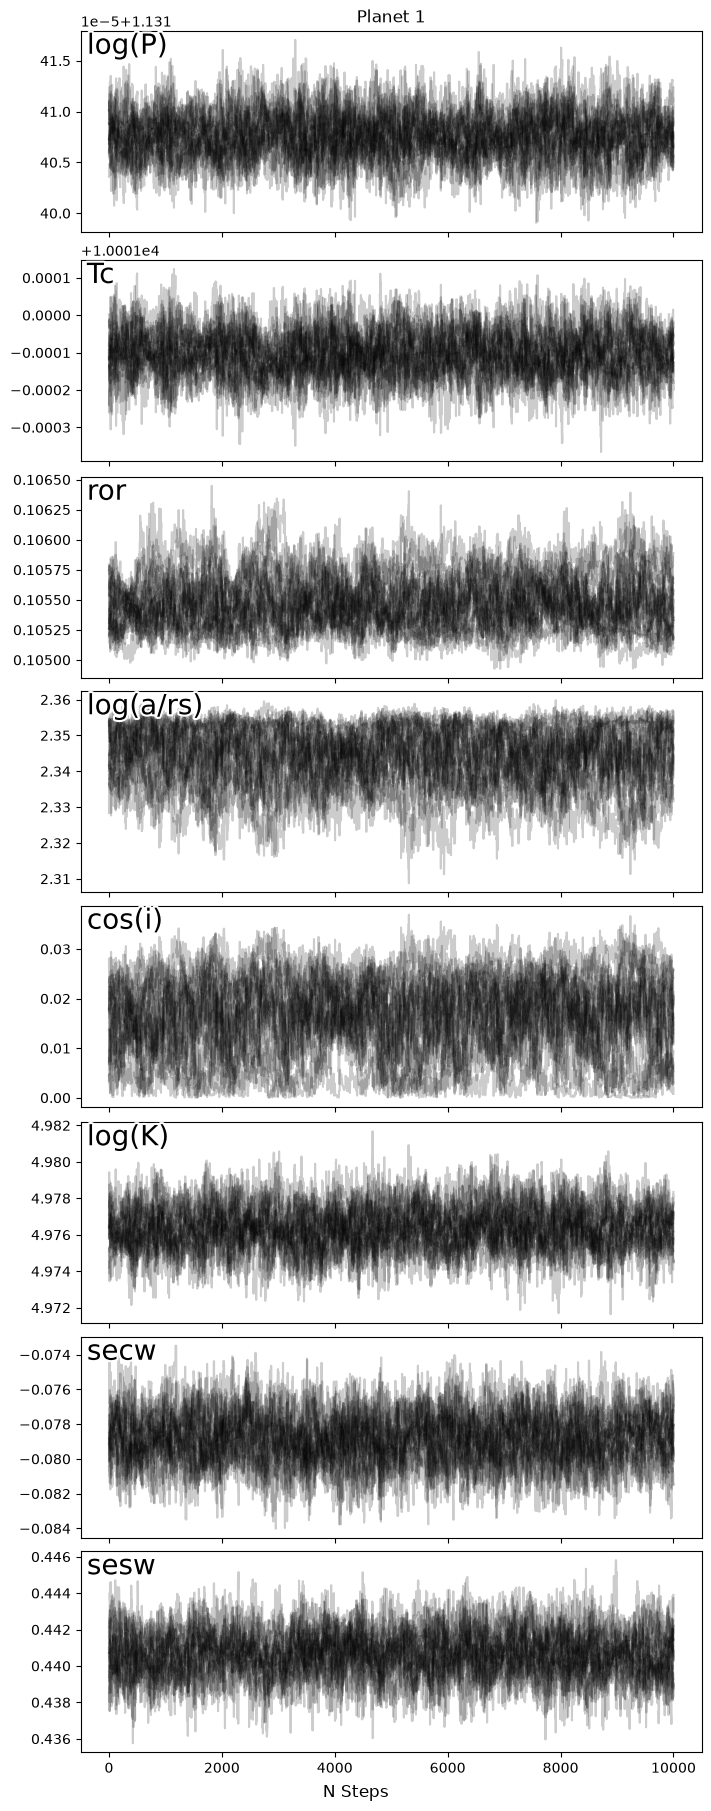

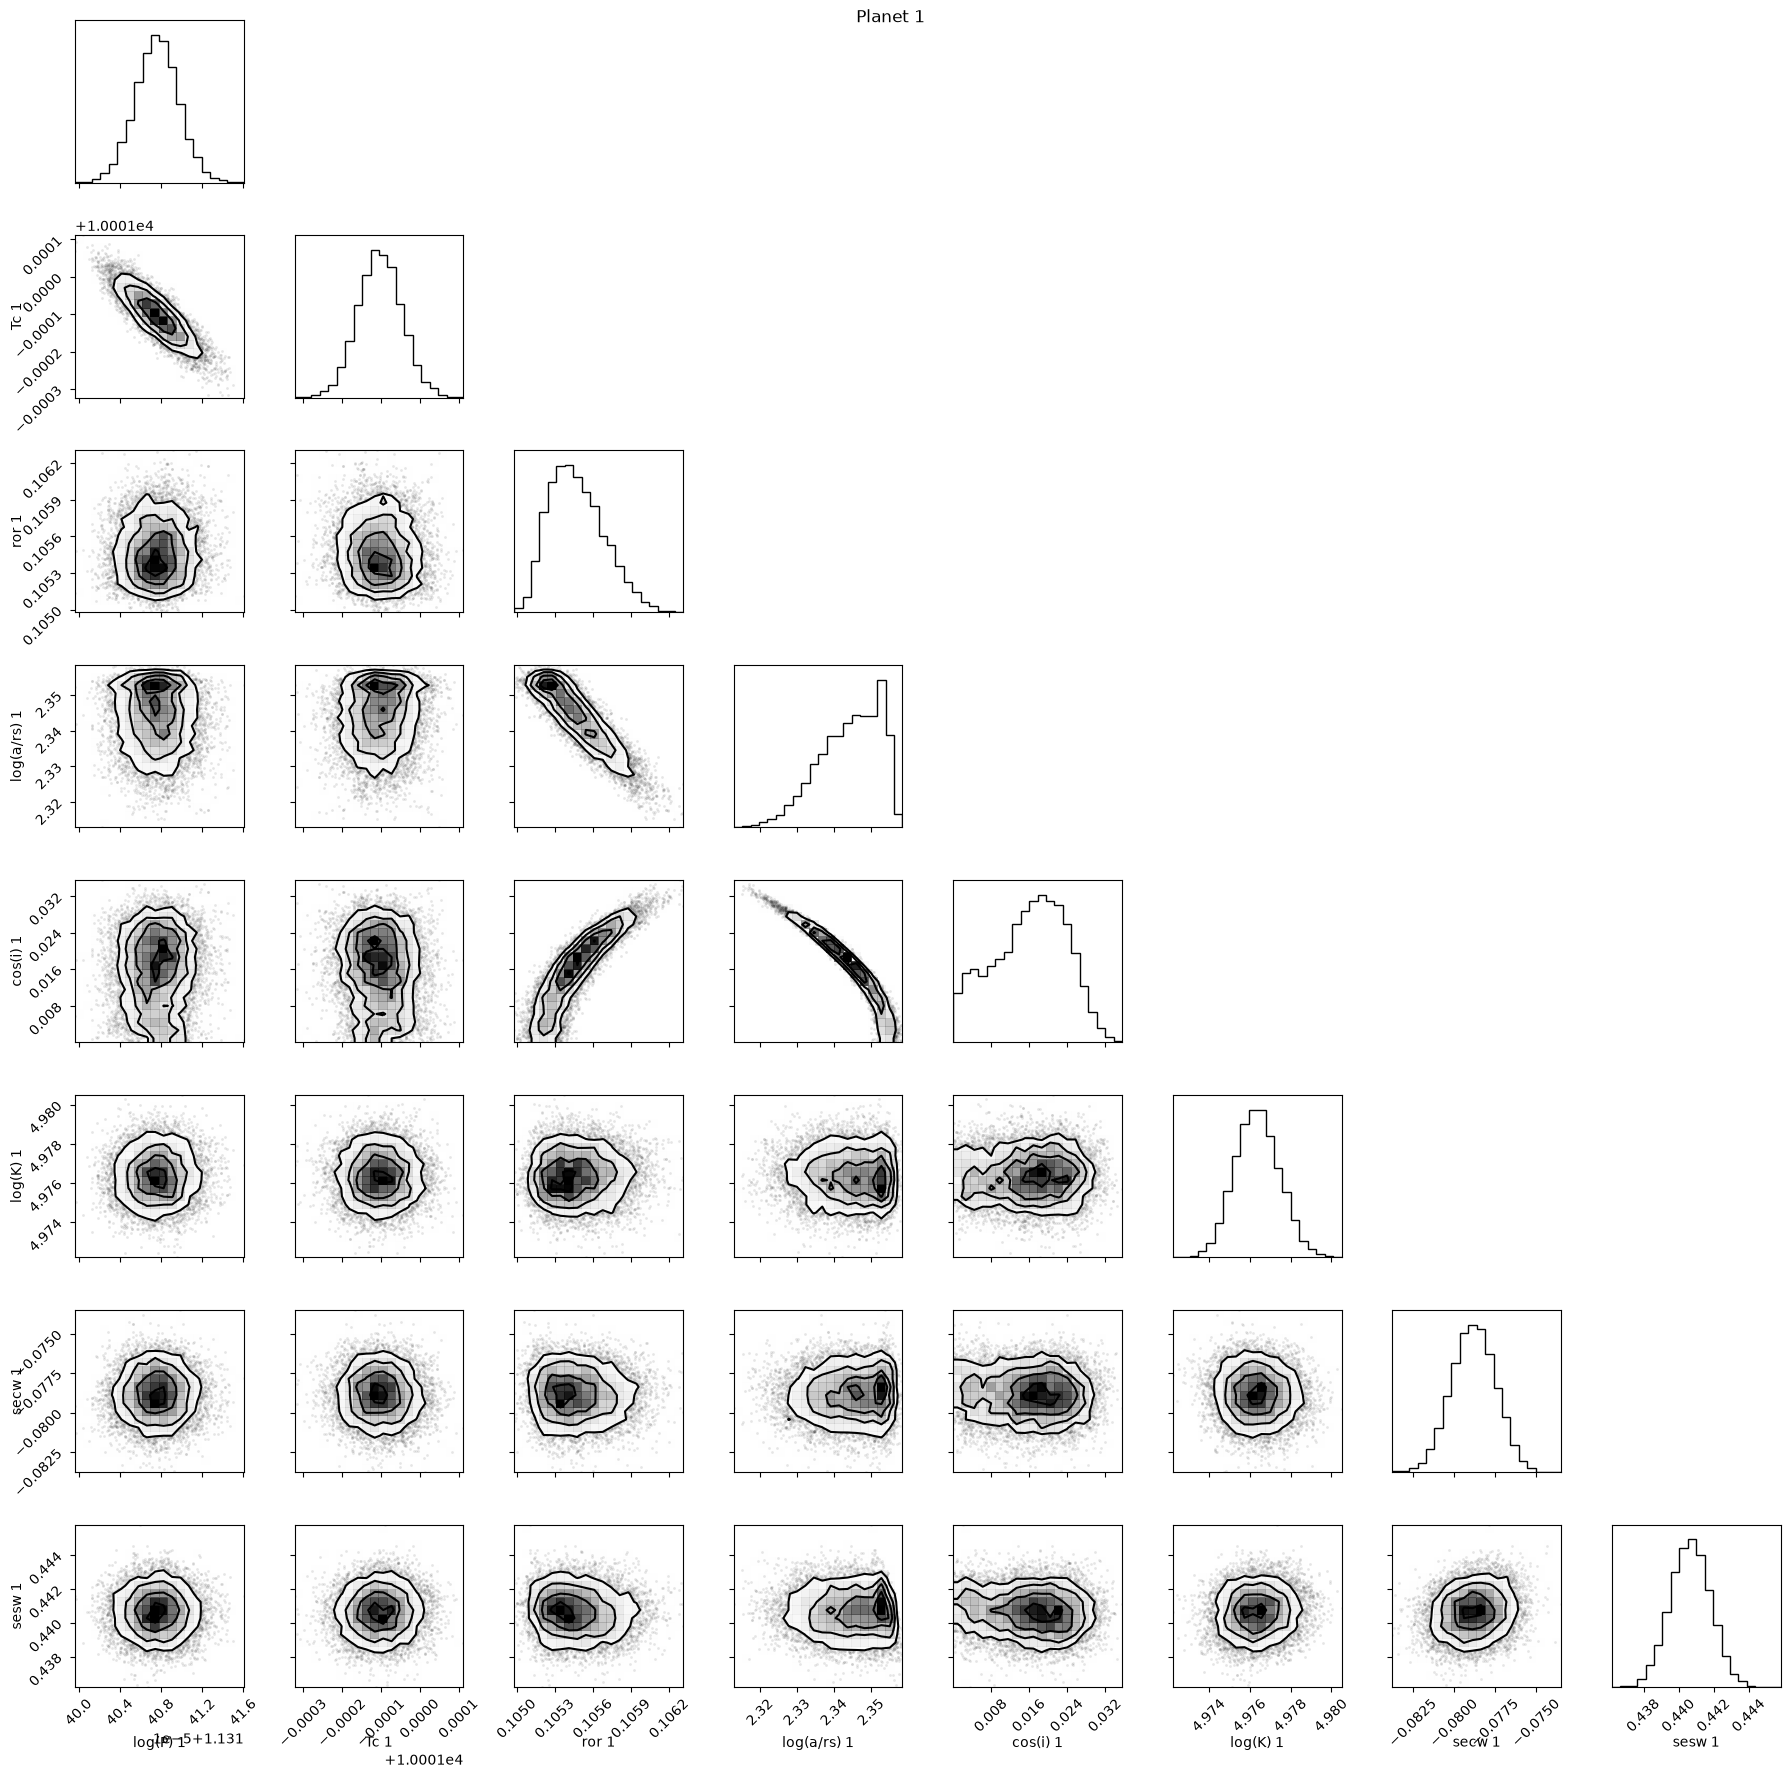


Generating light curves for plots.

Phase folded:

TESS:


  0%|          | 0/1000 [00:00<?, ?it/s]

Full:

ex_lc:


  0%|          | 0/1000 [00:00<?, ?it/s]

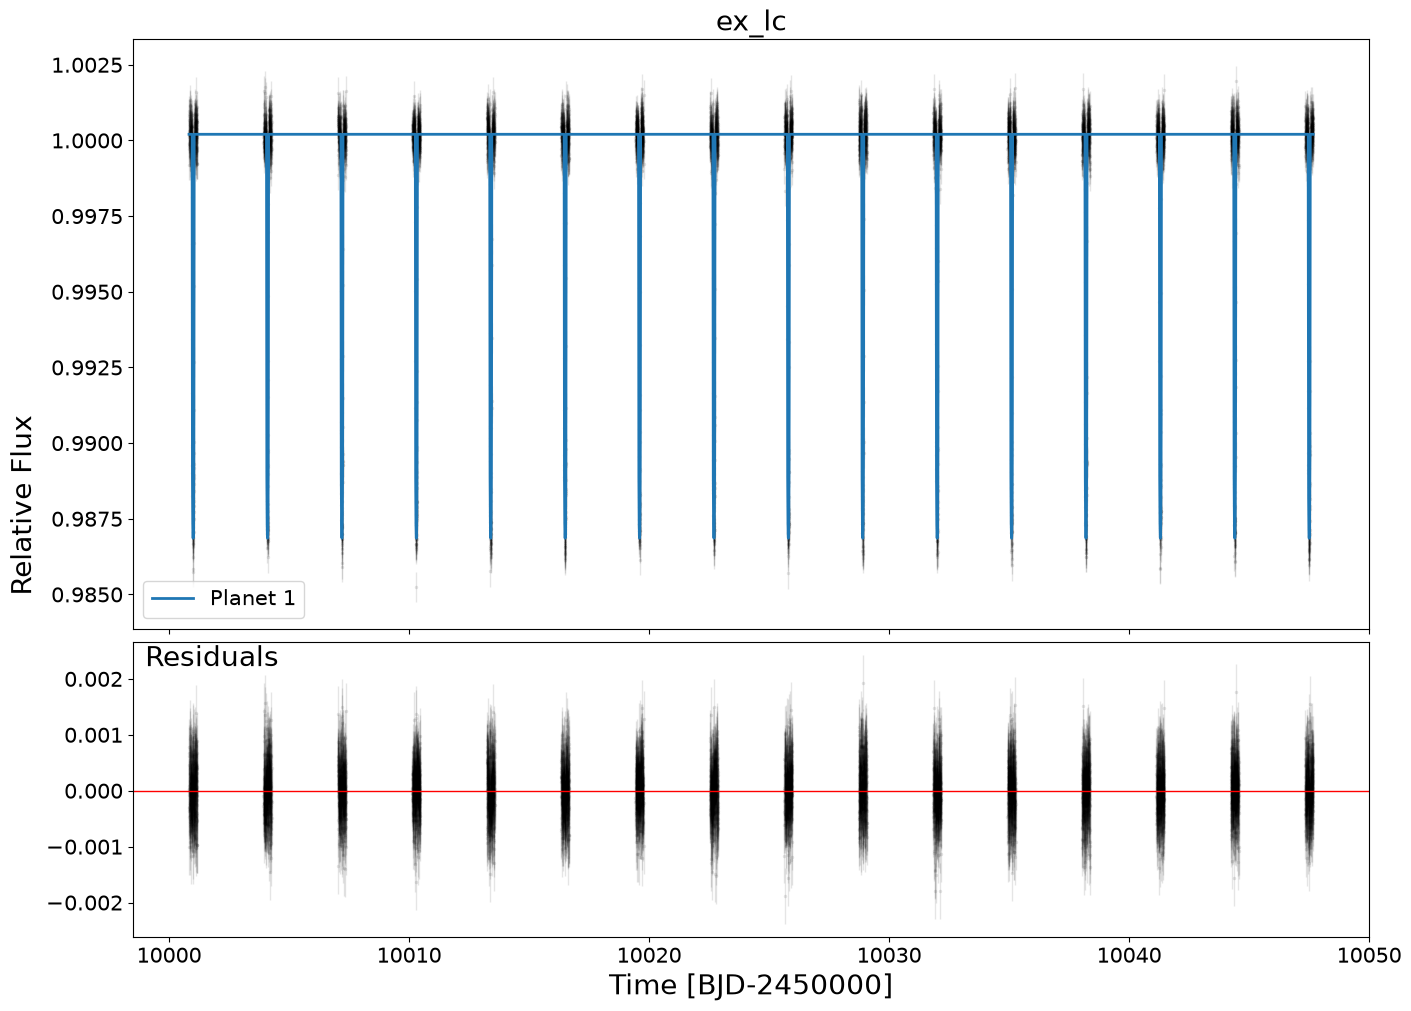

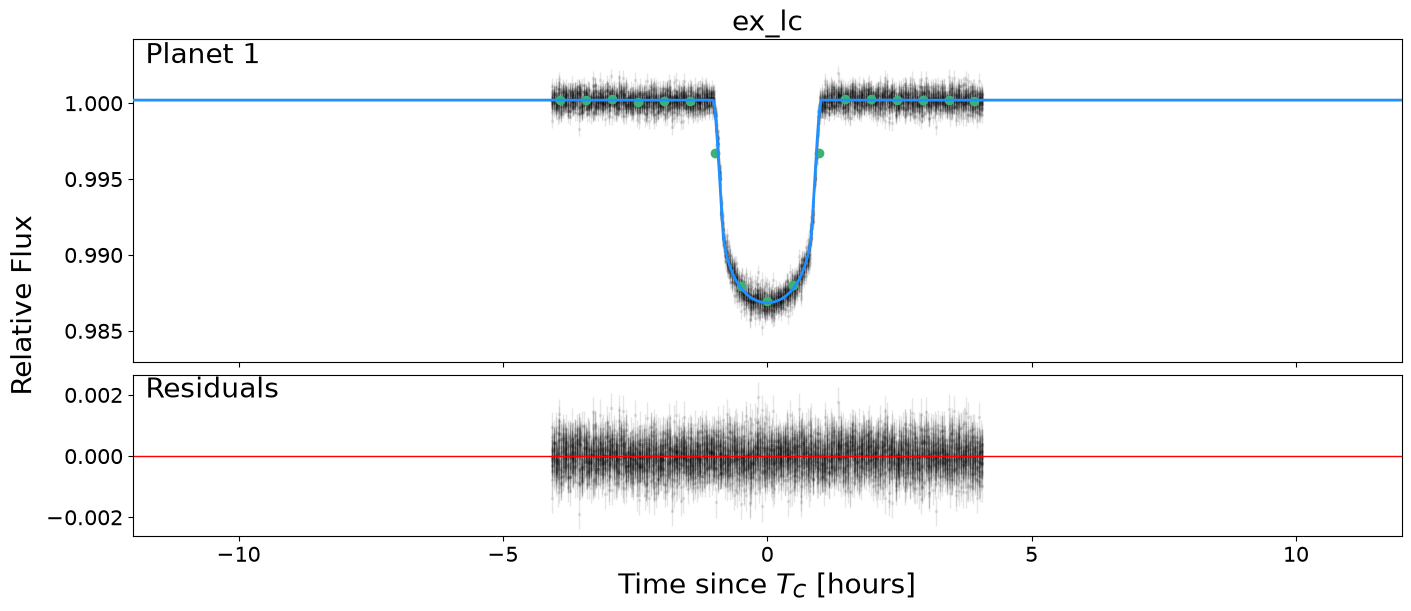


Generating RV models for plots.


  0%|          | 0/10000 [00:00<?, ?it/s]

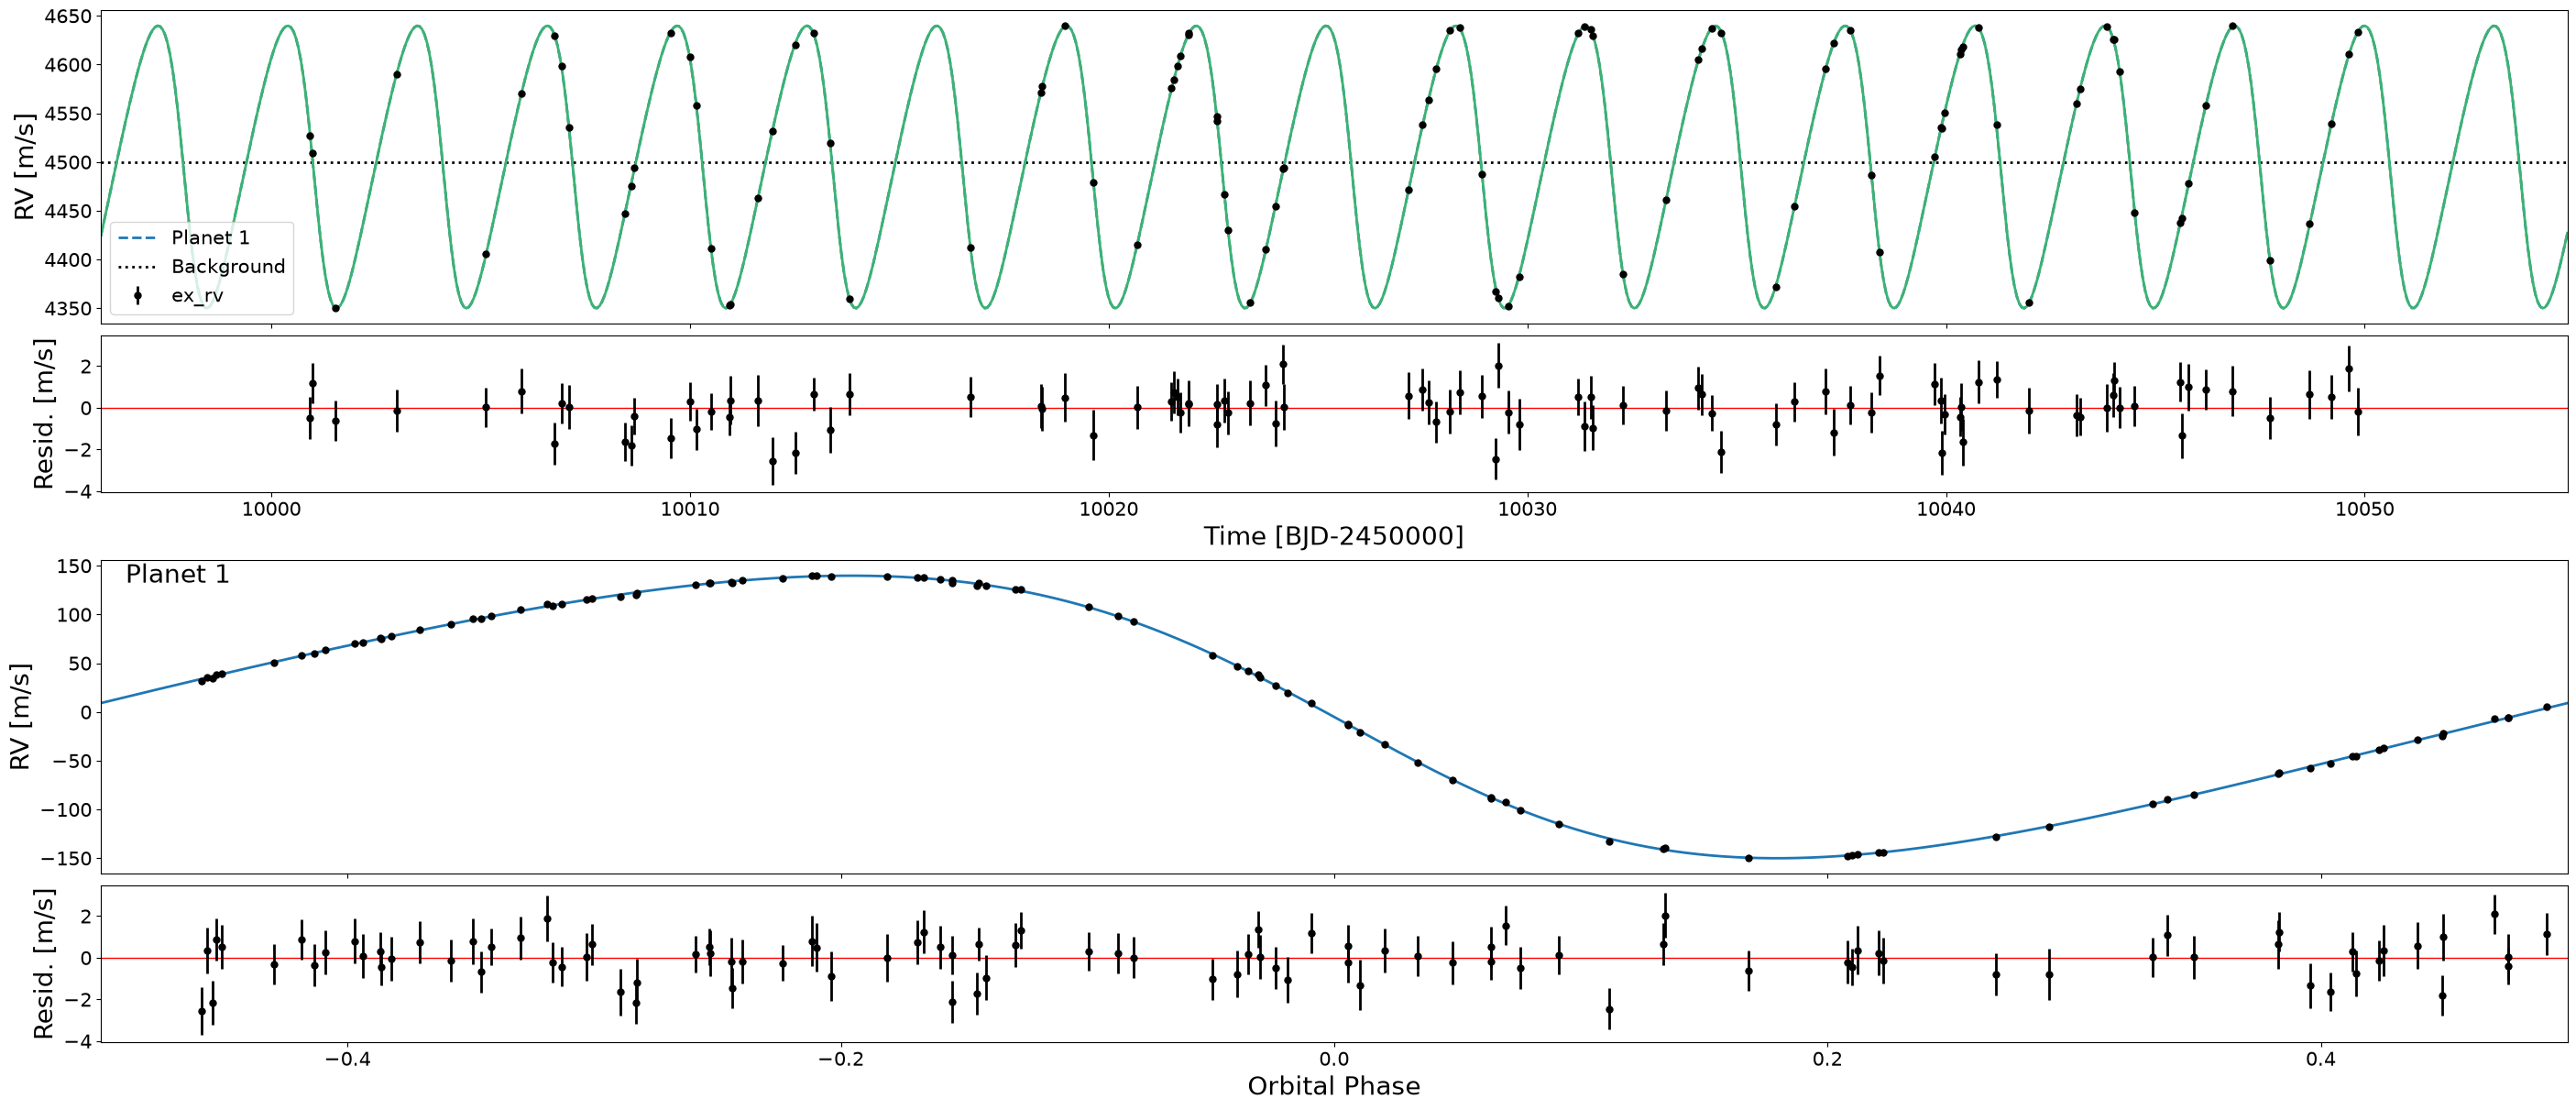


 Parameter     Units           Median                -Error                 +Error        
                                                                                          
----------- ----------- -------------------- ---------------------- ----------------------
   log(P) 1        days    1.131407565194748  2.073490375620324e-06 2.0502180961834426e-06
       Tc 1 BJD-2450000    10000.99989610732  5.465511821967084e-05 5.5998241805355065e-05
      ror 1              0.10544946493476554 0.00019494726375916815 0.00025095310957892747
log(a/rs) 1               2.3450871232609116   0.009761645596889856   0.007695689317035903
   cos(i) 1             0.016782367987026585   0.009545812644067554  0.0070377482589530395
   log(K) 1         m/s    4.976331931081521  0.0010378390442422614  0.0011268332836804618
     secw 1              -0.0788141420362302   0.001349107457680715  0.0013285714446206742
     sesw 1              0.44065547257434906  0.0011342442876505765  0.001139503788733842

In [6]:
name = 'example'
exs.fit(name = name, #The name of the run. This will set the names of output files and the plots folder, and allow you to load it back in using the name.
        nburn = 20000, #How many MCMC burn-in steps to run.
        nrun = 10000, #How many actual MCMC run steps to do.
        fit_transit = True, #Whether or not to fit the light curve data.
        fit_rv = True, #Whether or not to fit the RV data.
        fit_star = False, #Whether or not to fit stellar parameters.
        parallel = 'auto', #Whether or not to run MCMC chains in parallel. "auto" will determine optimal number of cores to use, or to use serial.
)

The fit was sucessful! Now, we will briefly cover everything that ``Alfred`` spit out above.

First, we were told the initial parameters for the fit, based on defaults and the guess we put into init_planets.txt.

Then, ``Alfred`` performed sigma clipping on the light curve data, to get rid of outlier points. It does this at 5 sigma by default, although that is a parameter than can be tuned or turned off. It first tried to optimize the likelihood function with a Nelder-Mead optimizer, then used the new parameters to generate a model. It used this model to find 8 points which were 5 sigma outliers. These are plotted as red x's in the residual of that initialization. Since the number of clipped points was low, a second round of sigma clipping was unnecessary. ``Alfred`` told us how many points were clipped in each data set (we only have one), and all together.

The new best guess at the fit parameters are printed out, after re-running the Nelder-Mead optimizer after sigma clipping. Small distributions of points around these values are used to initialize the MCMC chains.

Since we chose "auto" for the parallelization, it tells us that the built in function found 10 cores to be optimal (on my computer).

The MCMC burn-in was run, followed by the actual run steps, which were both tracked with a progress bar (which does not translate to this html page unfortunately). Then, the Gelman-Rubin statistic was printed for each parameter, a measure of how well the chains converged.

We then got a plot of the chains for the planetary parameters, as well as a corner plot for those same parameters. Everything looks to be in order, with some expected degeneracies in some parameters.

``Alfred`` then generated light curve models from the best fit parameters, first making phase-folded models for each filter (we only used TESS), then full models for each data set (we only had "ex_lc"). These were plotted with the data, first as a time-series for each data set, then phase-folded for each data set.

Next, an RV model was generated from the best fit parameters, and plotted both in time and in phase.

Finally, the median, lower 1 sigma (16th percentile), and upper 1 sigma (84th percentile) values were printed out for each fitted parameter, as well as some derived parameters such as the planet mass and equilibrium temperature.

All of these plots and a few more can be found in the directory in the Plots/example folder (or whatever name you chose for the run), and this table of values printed at the bottom can be found as example.txt (again, this will be different if you used a different name) in the Results folder.

If you would like to re-make certain plots, or otherwise fiddle with the data or results, this run can be loaded in the future by re-initializing an ``ExoSystem`` object in the directory and running:

In [7]:
exs.load_results(name)